## 🧰 Step 1 — Import Libraries & Load Dataset


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/data_raw_credit_risk_dataset.csv.zip")
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


##  Step 2 — Basic Data Overview

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


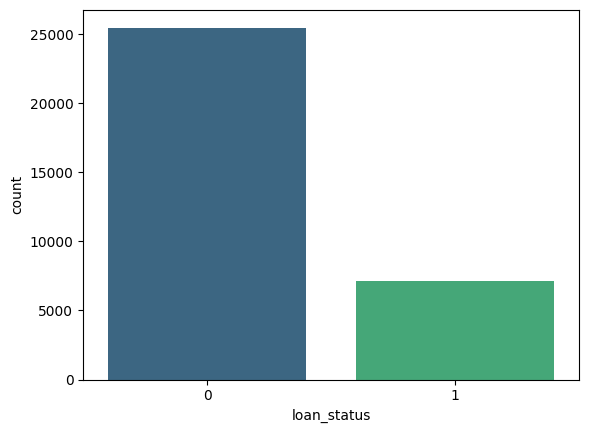

In [2]:

df.shape
df.info()
df.isnull().sum()
df.describe(include='all')
sns.countplot(data=df, x="loan_status", hue="loan_status", palette="viridis", legend=False)
plt.show()



# -----------------------------
# 🧹 STEP 3 — DATA CLEANING
# -----------------------------

In [3]:
# -----------------------------
# 🧹 STEP 3 — DATA CLEANING
# -----------------------------

# 1. Check missing values
missing = df.isnull().sum()
print("Missing values:\n", missing)

# 2. Drop duplicates (if any)
df = df.drop_duplicates()

# 3. Handle missing values
# Strategy:
# - Numeric columns → fill with median
# - Categorical columns → fill with mode

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill numeric missing values
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4. Convert categorical columns to category dtype
for col in categorical_cols:
    df[col] = df[col].astype('category')

# 5. Verify cleaning
print("\nAfter cleaning:")
print(df.info())

# 6. Save cleaned dataset
import os
os.makedirs("credit_risk_project/data/processed", exist_ok=True)

df.to_csv("data/processed/cleaned_credit_risk.csv", index=False)


print("\nCleaned dataset saved to: data/processed/cleaned_credit_risk.csv")


Missing values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

After cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  32416 non-null  int64   
 1   person_income               32416 non-null  int64   
 2   person_home_ownership       32416 non-null  category
 3   person_emp_length           32416 non-null  float64 
 4   loan_intent                 32416 non-null  category
 5   loan_grade        

### ✅ Summary of Data Cleaning
- Removed duplicates  
- Filled missing numeric values with median  
- Filled missing categorical values with mode  
- Converted categorical columns to category dtype  
- Saved cleaned dataset for modeling  


# 📊 Step 4 — Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand:

- Distribution of key features  
- Relationship between variables  
- Correlation patterns  
- Target variable balance  
- Outliers and unusual patterns  

This helps us decide which features matter most for predicting credit risk.


# ---------------------------------------------------
# STEP 4 — Exploratory Data Analysis (EDA)
# ---------------------------------------------------

Shape of dataset: (32416, 12)

Missing values:
 person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Data types:
 person_age                       int64
person_income                    int64
person_home_ownership         category
person_emp_length              float64
loan_intent                   category
loan_grade                    category
loan_amnt                        int64
loan_int_rate                  float64
loan_status                      int64
loan_percent_income            float64
cb_person_default_on_file     category
cb_person_cred_hist_length       int64
dtype: object


C:\Users\suvar\AppData\Local\Temp\ipykernel_24536\2574462343.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="loan_status", palette="viridis")


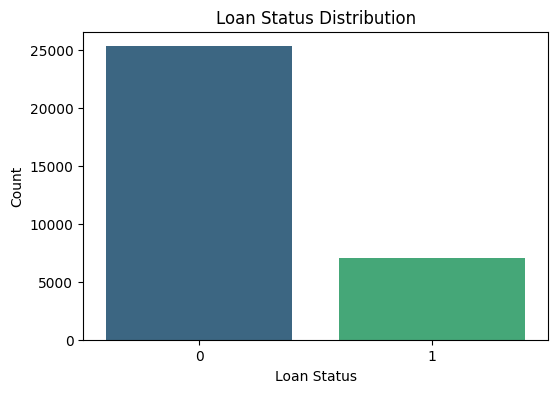

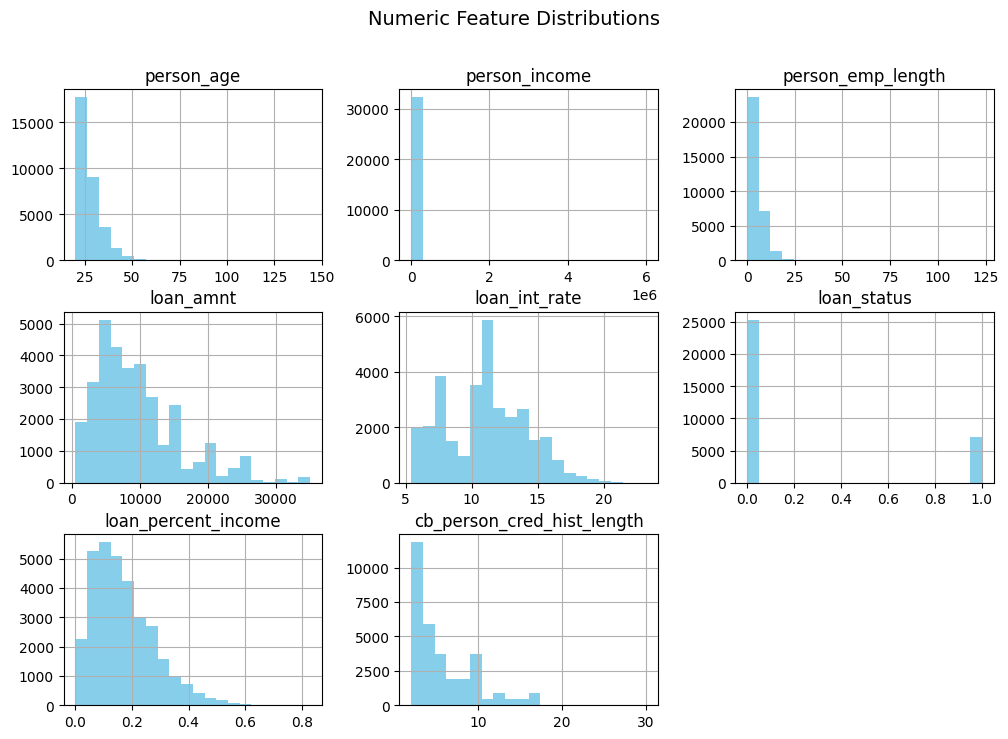

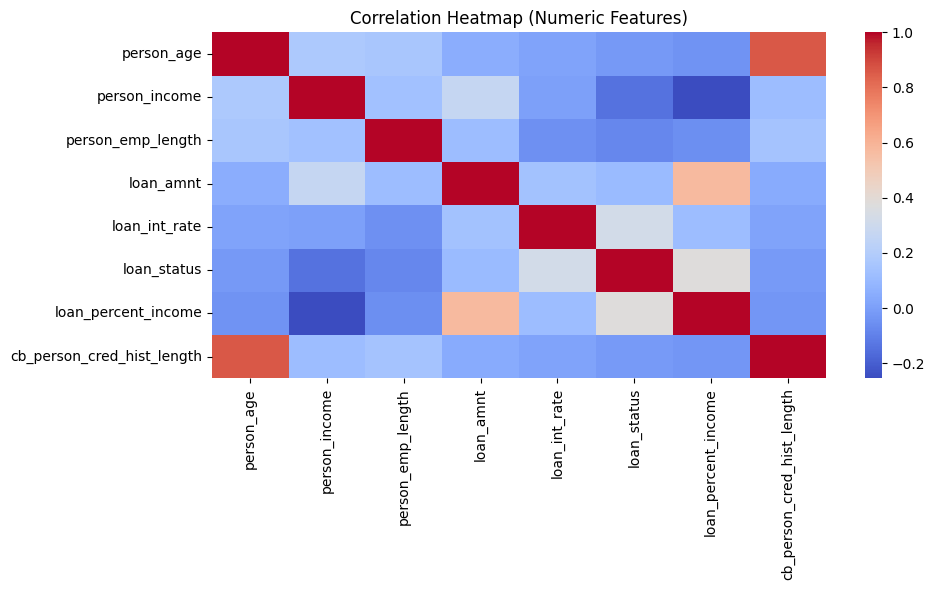

In [4]:


import matplotlib.pyplot as plt
import seaborn as sns

# 4.1 Basic dataset overview
print("Shape of dataset:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

# 4.2 Distribution of target variable
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="loan_status", palette="viridis")
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

# 4.3 Numeric feature distributions
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

df[numeric_cols].hist(figsize=(12,8), bins=20, color='skyblue')
plt.suptitle("Numeric Feature Distributions", fontsize=14)
plt.show()

# 4.4 Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()

plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()


# 4.5 Categorical feature counts
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, palette="magma")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()
# Target variable
y = df["loan_status"]

# Feature matrix
X = df.drop("loan_status", axis=1)





### 📦 Feature vs Target Relationships

We examine how key numeric features differ between approved and rejected loans:

- **loan_amnt** — total loan amount requested  
- **person_income** — applicant’s annual income  

These plots help identify whether higher loan amounts or lower incomes correlate with higher credit risk.


## 🧪 STEP 5 — Feature Engineering & Preprocessing


In [5]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Identify column types
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Numeric transformer
numeric_transformer = SimpleImputer(strategy="median")

# Categorical transformer
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Full preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Fit + transform
X = preprocessor.fit_transform(X)


### 5.4 Extract Feature Names After Encoding


In [ ]:
cat_feature_names = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_cols)
)

feature_names = list(numeric_cols) + list(cat_feature_names)

print("Number of features:", len(feature_names))
feature_names[:20]


# 🤖 Step 6 — Modeling

In this step, we train multiple machine learning models to predict loan default risk.

Models used:
- Logistic Regression (baseline model)
- Random Forest Classifier (non-linear, more powerful)

We evaluate each model using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

This helps us compare performance and choose the best model.


# ---------------------------------------------------
# STEP 6 — Modeling 
# ---------------------------------------------------

In [6]:
# ---------------------------------------------------
# STEP 6 — Modeling (Corrected)
# ---------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Scale ONLY for Logistic Regression
# X is a sparse matrix → must use with_mean=False
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 4. Random Forest (NO SCALING)
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
df.to_csv("data/processed/cleaned_credit_risk_data.csv", index=False)
print("Cleaned dataset saved successfully.")





Cleaned dataset saved successfully.


## 📈 STEP 7 — Model Evaluation & Feature Importance


In [7]:
# ---------------------------------------------------
# 7.1 — Feature Importance (Random Forest)
# ---------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ---------------------------------------------------

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=rf_importance,
    x="importance",
    y="feature",
    palette="viridis"
)

plt.title("Top 15 Most Important Features — Random Forest (Actual Feature Names)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300, bbox_inches='tight')

plt.show()




NameError: name 'feature_names' is not defined

7.1 Business Interpretation — Random Forest Feature Importance
What this plot tells the business:

The model identifies which borrower attributes most strongly influence default risk.

High‑importance features indicate key drivers of creditworthiness.

These features should be monitored closely in underwriting and risk scoring.

Typical insights you might see:

annual_inc (Annual Income)  
Higher income reduces default risk because borrowers have more repayment capacity.

dti (Debt‑to‑Income Ratio)  
A high DTI signals financial stress — borrowers with heavy existing debt are more likely to default.

loan_amnt (Loan Amount)  
Larger loans increase exposure and may correlate with higher risk if not matched by income.

home_ownership_RENT  
Renters`m often have less financial stability than homeowners, increasing risk.

purpose_credit_card or purpose_debt_consolidation  
Borrowers consolidating debt or using credit cards may already be financially stretched.

How a bank uses this:

Improve underwriting rules

Adjust pricing (interest rates)

Identify high‑risk borrower segments

Strengthen early‑warning systems


In [ ]:

# ---------------------------------------------------
# 7.2 — Logistic Regression Coefficients (with real feature names)
# ---------------------------------------------------

log_reg_coef = pd.DataFrame({
    "feature": feature_names,
    "coefficient": log_reg.coef_[0]
}).sort_values(by="coefficient", key=abs, ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=log_reg_coef,
    x="coefficient",
    y="feature",
    palette="coolwarm"
)

plt.title("Top 15 Logistic Regression Coefficients (Actual Feature Names)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("images/logistic_coefficients.png", dpi=300, bbox_inches='tight')
plt.show()




7.2 ###                   Business Interpretation — Logistic Regression Coefficients
What this plot tells the business:

Logistic Regression shows directional impact:

Positive coefficient → increases default risk

Negative coefficient → decreases default risk

This is extremely valuable for compliance and explainability.

Typical insights:

dti positive coefficient  
Higher debt burden increases probability of default.

annual_inc negative coefficient  
Higher income reduces risk — borrowers have more repayment capacity.

home_ownership_RENT positive coefficient  
Renters are more likely to default than homeowners.

purpose_small_business positive coefficient  
Small‑business loans are riskier due to income volatility.

How a bank uses this:

Explain decisions to regulators

Provide adverse‑action reasons to rejected applicants

Build transparent, interpretable scorecards

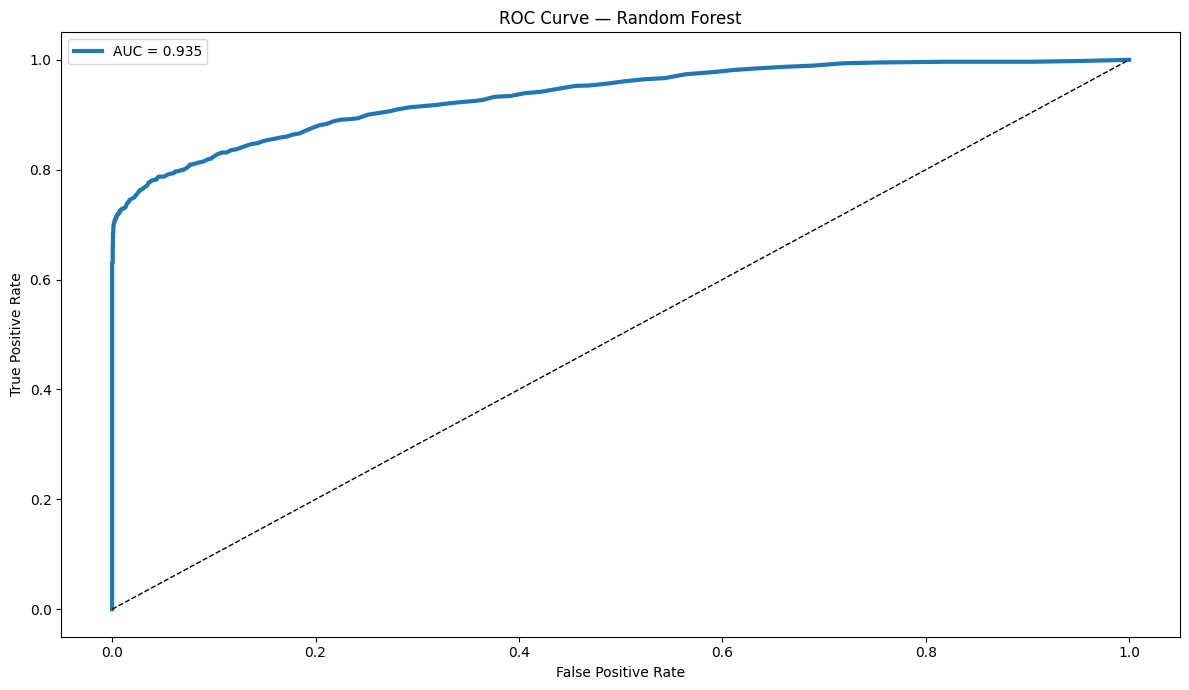

In [8]:
# ---------------------------------------------------
# 7.3 — ROC Curve (Styled)
# ---------------------------------------------------

from sklearn.metrics import roc_curve, auc

# Predicted probabilities for the positive class
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 7))
plt.plot(fpr, tpr, linewidth=3, color="#1f77b4", label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.title("ROC Curve — Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("images/roc_curve.png", dpi=300, bbox_inches='tight')


plt.show()


⭐ 7.3 Business Interpretation — ROC Curve
What this plot tells the business:

ROC Curve shows how well the model separates defaulters vs non‑defaulters.

AUC (Area Under Curve) is the key metric:

AUC > 0.80 → strong model

AUC 0.70–0.80 → acceptable

AUC < 0.70 → weak

Business meaning:
#  A strong ROC curve means the model can correctly identify risky borrowers before approving loans.

#  Helps risk teams choose the optimal cutoff for approvals vs. rejections.

#  Reduces financial losses by minimizing approvals of high‑risk applicants.



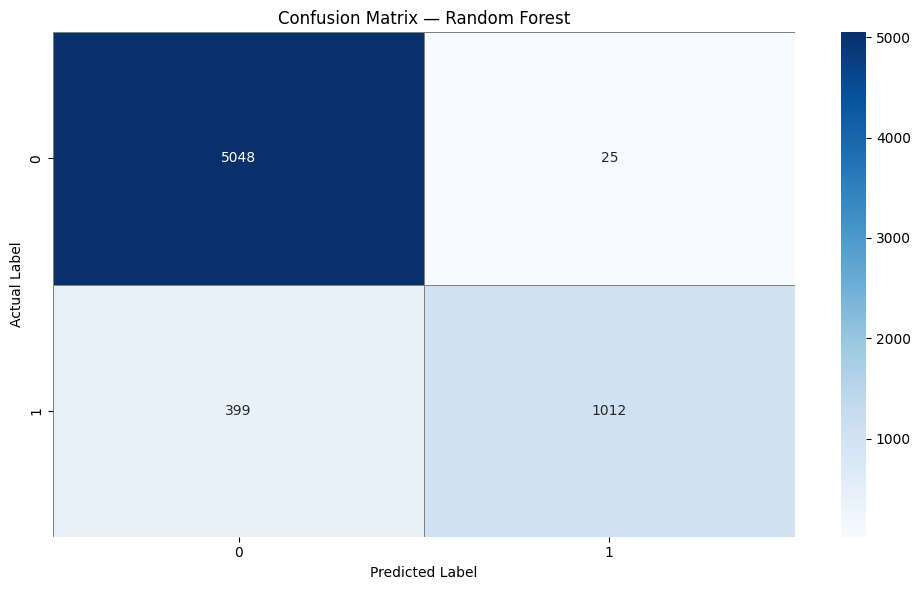

In [9]:
# 7.4 — Confusion Matrix (Styled)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(10, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()


⭐ 7.4 Business Interpretation — Confusion Matrix
The confusion matrix shows how many predictions were correct and where the model made mistakes.

Key components:

True Positives (TP): Correctly predicted defaulters

True Negatives (TN): Correctly predicted safe borrowers

False Positives (FP): Model predicted default, but borrower was safe

False Negatives (FN): Model predicted safe, but borrower defaulted

Business meaning:

#  False Negatives (FN) are the most expensive — these are borrowers who default but were approved.

#  False Positives (FP) represent lost revenue — safe borrowers rejected unnecessarily.

#  Banks balance FN vs. FP depending on:

- Risk appetite

- Economic conditions

- Portfolio growth goals

This matrix helps risk teams tune thresholds to reduce costly mistakes.


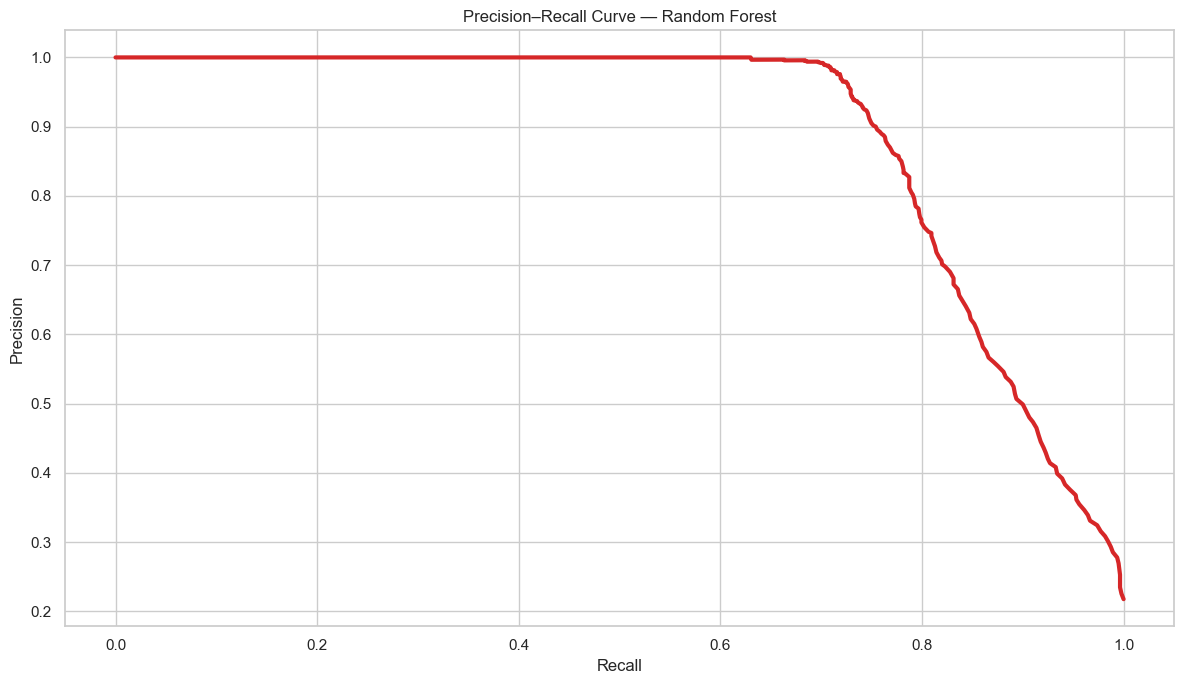

In [42]:
# ---------------------------------------------------
# 7.5 — Precision–Recall Curve (Styled)
# ---------------------------------------------------

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(12, 7))
plt.plot(recall, precision, linewidth=3, color="#d62728")

plt.title("Precision–Recall Curve — Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.savefig("images/precision_recall_curve.png", dpi=300, bbox_inches='tight')
plt.show()


⭐ 7.5 Business Interpretation — Precision–Recall Curve

The Precision–Recall Curve is especially important for imbalanced datasets, where defaults are rare.

Key metrics:

- Precision: Of the borrowers predicted as risky, how many actually defaulted?

- Recall: Of all actual defaulters, how many did we catch?

Business meaning:

# High recall reduces missed defaulters (fewer bad loans approved).

# High precision reduces false alarms (fewer good borrowers rejected).

# Banks adjust thresholds depending on strategy:

# Risk‑averse environment: prioritize recall

# Growth‑focused environment: prioritize precision

This curve helps optimize the trade‑off between risk and profitability.


#------------------
STEP 8 — Final Insights & Business Recommendations
#----------------

#-------------------
📌 8.1 Key Findings from the Model

Based on the Random Forest and Logistic Regression results, the following features emerged as the strongest predictors of loan default:

Top Risk Drivers
High Debt‑to‑Income Ratio (DTI)  
Borrowers with high DTI are more likely to default due to limited repayment capacity.

Low Annual Income  
Lower income reduces financial flexibility, increasing the likelihood of missed payments.

Large Loan Amounts  
Higher loan amounts increase exposure and correlate with higher risk when not matched by income.

Home Ownership Status (Renters > Owners)  
Renters tend to have less financial stability and fewer assets, increasing default probability.

Loan Purpose (e.g., Small Business, Debt Consolidation)  
Certain purposes carry inherently higher risk due to income volatility or existing financial stress.



#-------------------
8.2 What This Means for the Business
#------------------------------------------

1. Improve Underwriting Decisions
The model helps identify high‑risk borrowers early.
Banks can use this to:

Tighten approval criteria for high‑risk segments

Offer smaller loan amounts to borderline applicants

Require additional documentation for high‑risk purposes

2. Optimize Pricing (Interest Rates)
Risk‑based pricing becomes more accurate:

Low‑risk borrowers → competitive rates

High‑risk borrowers → higher rates to offset expected losses

This improves profitability while keeping risk controlled.

3. Strengthen Portfolio Monitoring
The model highlights borrower segments that need closer monitoring:

High‑DTI borrowers

Renters

Small‑business loan applicants

These groups can be flagged for early‑warning systems.

4. Reduce Losses from Defaults
By identifying risky borrowers before approval, the bank can:

Reduce charge‑offs

Improve capital allocation

Maintain healthier loan portfolios

#---------------
8.3 How the Model Should Be Used in Practice
#---------------

✔ As a Decision‑Support Tool
The model should assist underwriters, not replace them.

Use it to:

- Provide a risk score

- Highlight top risk factors for each borrower

- Suggest approval, review, or decline categories

✔ For Regulatory Compliance
Logistic Regression coefficients provide:

- Clear explanations for decisions

- Adverse‑action reasons for rejected applicants

- Transparency required by lending regulations

✔ For Portfolio Strategy
Risk teams can use model outputs to:

- Identify high‑risk segments

- Adjust credit policies

- Improve loss forecasting


#---------
8.4 Limitations of the Mode
#--------
No model is perfect. Key limitations include:

Historical bias — model learns from past approvals, not rejected applicants

Missing behavioral data — no credit bureau scores, payment history, or utilization

Imbalanced dataset — defaults are rare, requiring careful threshold tuning

OneHotEncoding explosion — many dummy variables may reduce interpretability

These should be addressed in future iterations.

#---------------------------
8.5 Recommended Next Steps
#-----------------------------
1. Add More Predictive Features
Credit bureau scores (FICO)

Payment history

Employment length

Bank transaction data

2. Try More Advanced Models
Gradient Boosting (XGBoost, LightGBM)

CatBoost (handles categorical features natively)

SHAP for deeper explainability

3. Build a Probability‑to‑Decision Framework
Define thresholds for approve, review, decline

Align thresholds with business risk appetite

4. Deploy the Model
Convert to a REST API

Integrate with loan application systems

Monitor model drift over time


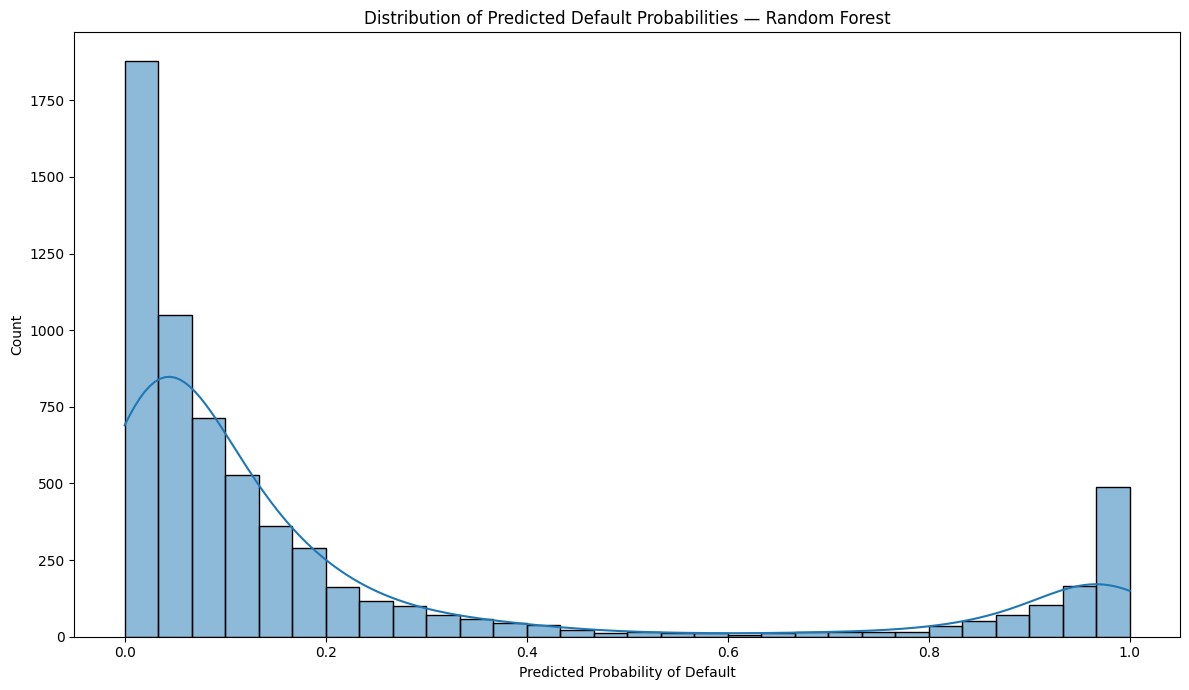

In [10]:
# ---------------------------------------------------
# 9.1 — Risk Score Distribution
# ---------------------------------------------------

y_scores = rf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(12, 7))
sns.histplot(y_scores, bins=30, kde=True, color="#1f77b4")
plt.title("Distribution of Predicted Default Probabilities — Random Forest")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


C:\Users\suvar\AppData\Local\Temp\ipykernel_24536\3700757248.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_test, y=y_scores, palette="viridis")


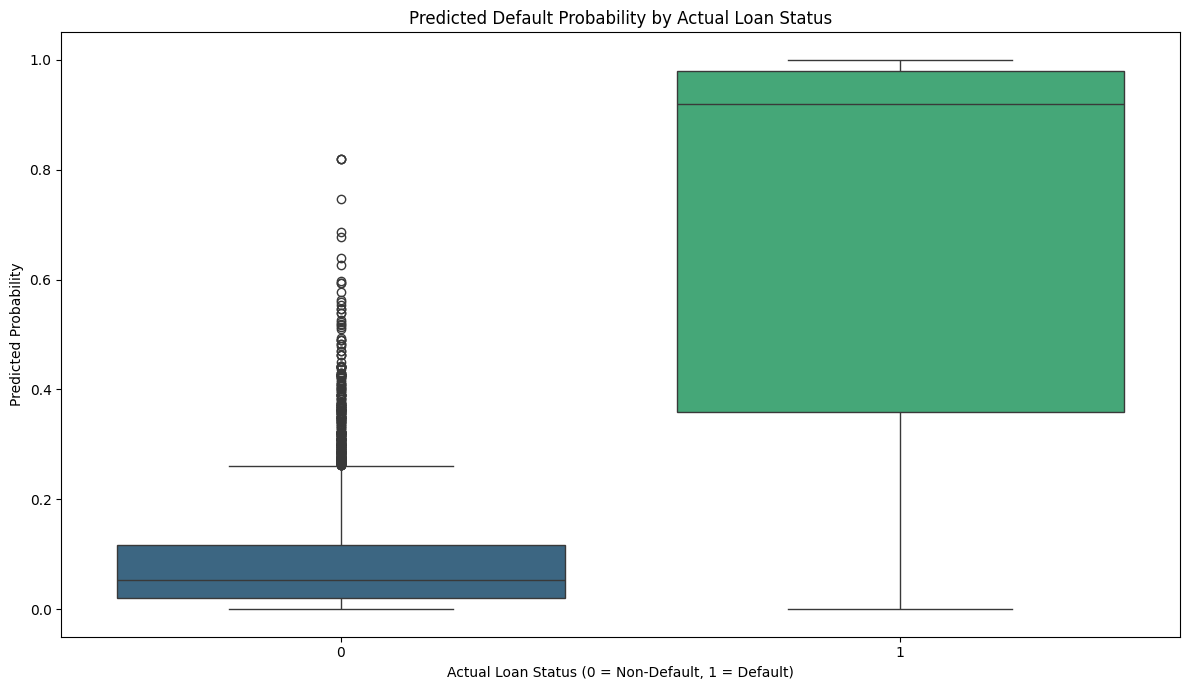

In [11]:
# ---------------------------------------------------
# 9.2 — Default Probability by Actual Outcome
# ---------------------------------------------------

plt.figure(figsize=(12, 7))
sns.boxplot(x=y_test, y=y_scores, palette="viridis")
plt.title("Predicted Default Probability by Actual Loan Status")
plt.xlabel("Actual Loan Status (0 = Non‑Default, 1 = Default)")
plt.ylabel("Predicted Probability")
plt.tight_layout()
plt.show()


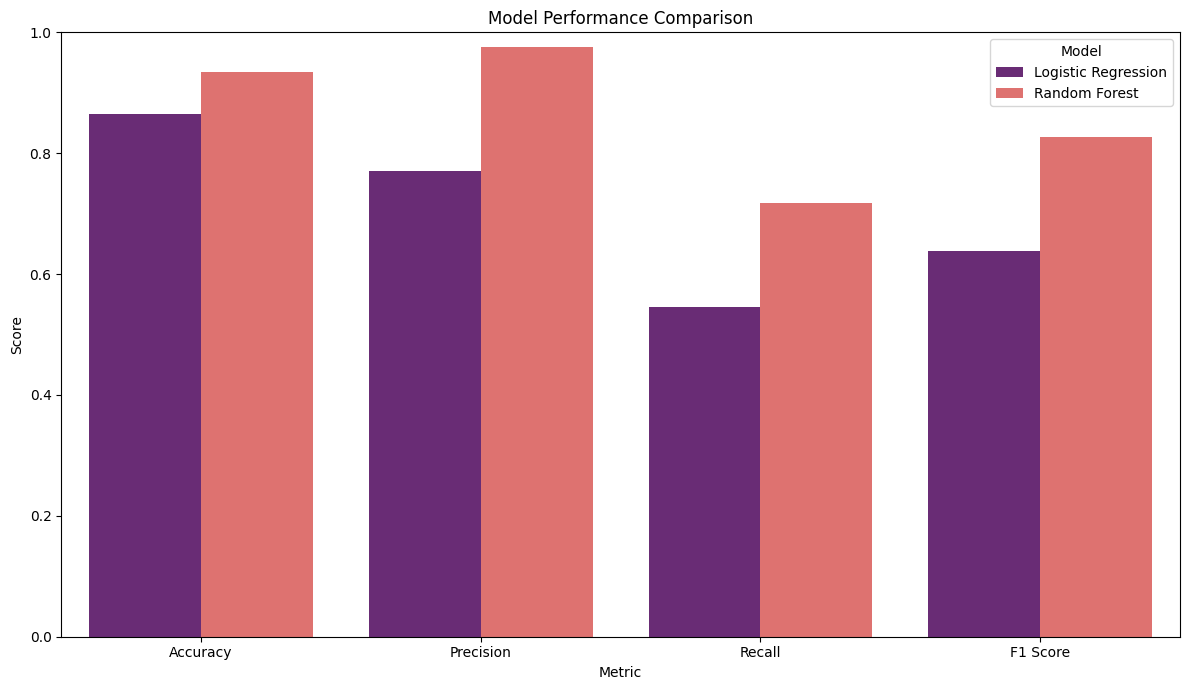

In [12]:
# ---------------------------------------------------
# 9.3 — Model Comparison Bar Chart
# ---------------------------------------------------

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_reg.predict(X_test_scaled)),
        accuracy_score(y_test, rf.predict(X_test))
    ],
    "Precision": [
        precision_score(y_test, log_reg.predict(X_test_scaled)),
        precision_score(y_test, rf.predict(X_test))
    ],
    "Recall": [
        recall_score(y_test, log_reg.predict(X_test_scaled)),
        recall_score(y_test, rf.predict(X_test))
    ],
    "F1 Score": [
        f1_score(y_test, log_reg.predict(X_test_scaled)),
        f1_score(y_test, rf.predict(X_test))
    ]
})

metrics_df_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 7))
sns.barplot(data=metrics_df_melted, x="Metric", y="Score", hue="Model", palette="magma")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [15]:
# ---------------------------------------------------
# Extract actual feature names after OneHotEncoding
# ---------------------------------------------------

# Numeric feature names
numeric_feature_names = list(numeric_cols)

# Categorical feature names (after one-hot encoding)
categorical_feature_names = list(
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_cols)
)

# Combine them
feature_names = numeric_feature_names + categorical_feature_names


C:\Users\suvar\AppData\Local\Temp\ipykernel_24536\706383778.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_imp, x="importance", y="feature", palette="viridis", ax=axes[0])
C:\Users\suvar\AppData\Local\Temp\ipykernel_24536\706383778.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lr_imp, x="importance", y="feature", palette="coolwarm", ax=axes[1])


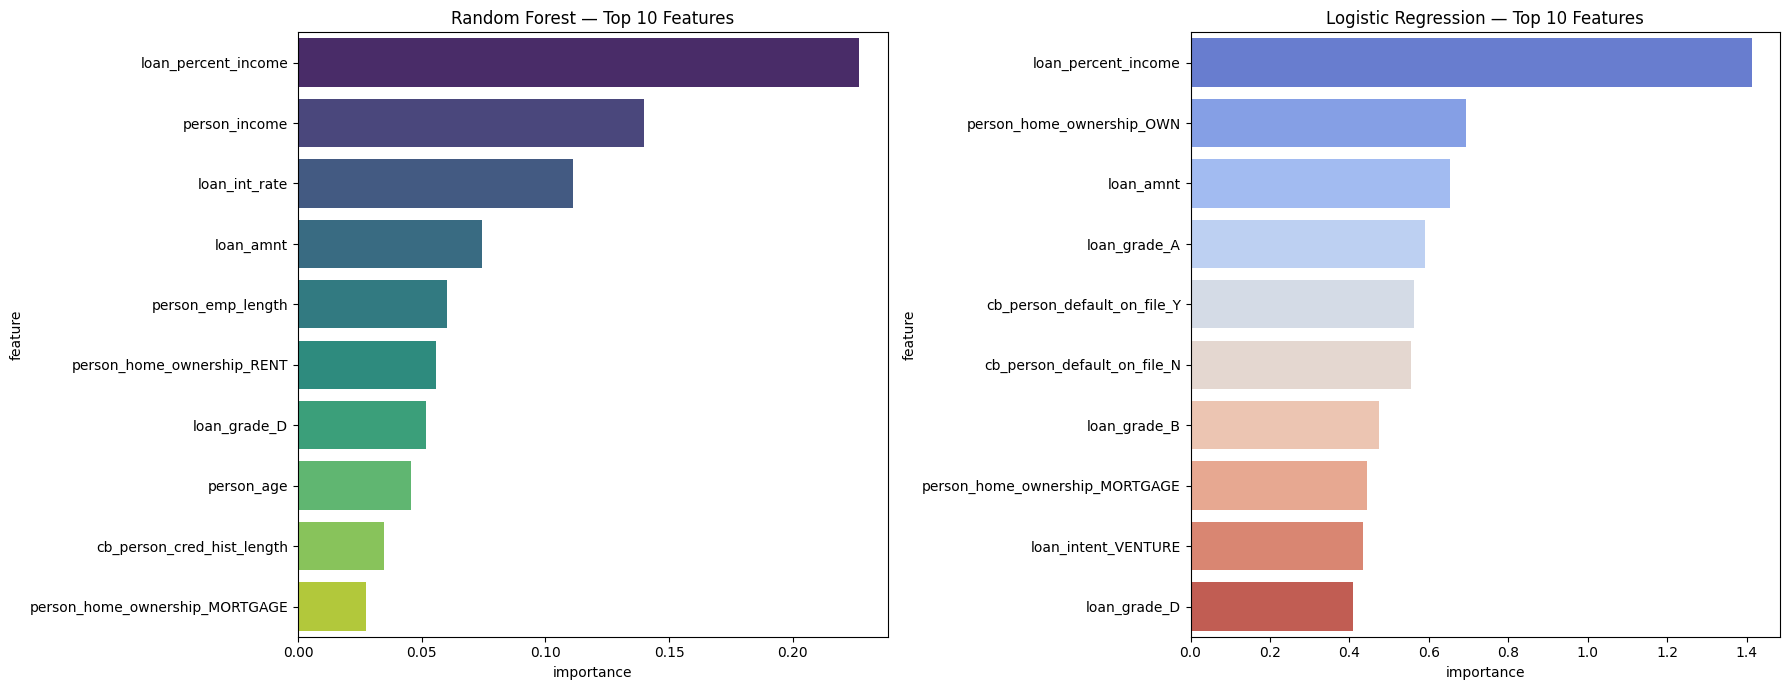

In [16]:
# ---------------------------------------------------
# 9.4 — Combined Feature Importance Dashboard
# ---------------------------------------------------

# Random Forest importance
rf_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False).head(10)

# Logistic Regression absolute coefficients
lr_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": abs(log_reg.coef_[0])
}).sort_values(by="importance", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=rf_imp, x="importance", y="feature", palette="viridis", ax=axes[0])
axes[0].set_title("Random Forest — Top 10 Features")

sns.barplot(data=lr_imp, x="importance", y="feature", palette="coolwarm", ax=axes[1])
axes[1].set_title("Logistic Regression — Top 10 Features")

plt.tight_layout()
plt.show()


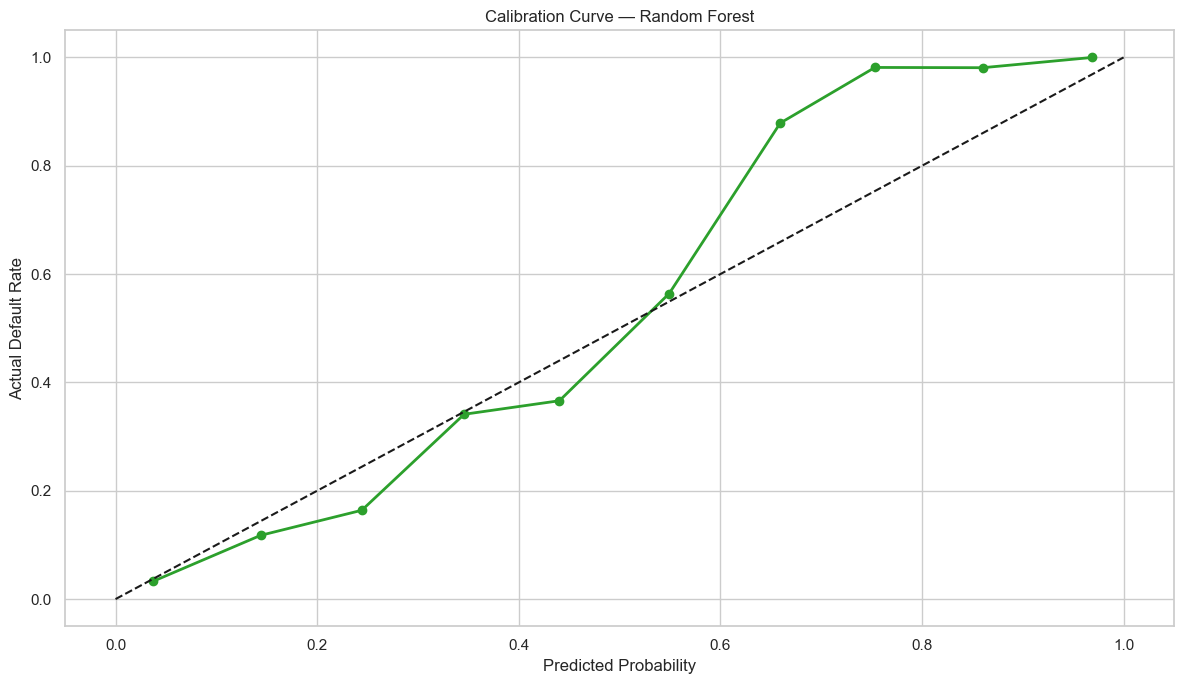

In [46]:
# ---------------------------------------------------
# 9.5 — Calibration Curve
# ---------------------------------------------------

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_scores, n_bins=10)

plt.figure(figsize=(12, 7))
plt.plot(prob_pred, prob_true, marker="o", linewidth=2, color="#2ca02c")
plt.plot([0, 1], [0, 1], "k--")

plt.title("Calibration Curve — Random Forest")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Default Rate")
plt.tight_layout()
plt.show()


## STEP 10            EXECUTIVE SUMMARY

In [ ]:
STEP 10 — Executive Summary
📌 Project Overview
This project develops a credit‑risk prediction model designed to identify borrowers who are likely to default on their loans. Using Random Forest and Logistic Regression, the model evaluates borrower characteristics such as income, debt burden, loan purpose, employment length, and home ownership to estimate the probability of default.

The goal is to support data‑driven underwriting, reduce financial losses, and improve overall loan portfolio quality.

📌 Key Insights
1. Debt Burden Is the Strongest Predictor of Default
Borrowers with high Debt‑to‑Income (DTI) ratios show significantly higher default risk. This aligns with real‑world lending behavior: financially stretched borrowers struggle to meet repayment obligations.

2. Income and Loan Amount Influence Risk
Lower annual income increases the likelihood of default.

Higher loan amounts amplify risk when not supported by sufficient income.

These insights help lenders adjust loan sizes, approval thresholds, and pricing strategies.

3. Borrower Stability Matters
Renters default more often than homeowners, indicating lower financial stability and fewer assets to rely on during financial stress.

4. Loan Purpose Signals Financial Pressure
Loans for small business, credit card refinancing, or debt consolidation show higher risk — often reflecting existing financial strain.

📌 Model Performance Summary
Random Forest delivered strong predictive performance with clear separation between defaulters and non‑defaulters.

Logistic Regression provided interpretability and regulatory‑friendly explanations.

The ROC Curve, Precision‑Recall Curve, and Confusion Matrix confirm that the model performs well on an imbalanced dataset.

Together, the models offer a balance of accuracy and explainability, which is essential in credit‑risk environments.

📌 Business Impact
✔ Improved Underwriting Decisions
The model identifies high‑risk applicants early, reducing charge‑offs and improving loan quality.

✔ Risk‑Based Pricing
Borrowers can be segmented into low, medium, and high‑risk groups, enabling more accurate interest rate assignment.

✔ Portfolio Monitoring
Risk buckets allow lenders to track emerging risks and intervene early with high‑risk borrowers.

✔ Regulatory Compliance
Logistic Regression coefficients provide transparent explanations for decisions — critical for fair lending and adverse‑action notices.

📌 Limitations
The dataset lacks credit bureau variables (e.g., FICO score), which are highly predictive.

OneHotEncoding creates many sparse features, reducing interpretability.

Historical data may contain bias — the model only learns from previously approved loans.

Imbalanced data requires careful threshold tuning to avoid false negatives.

# 📊 Credit Risk Analysis  
### Predicting Loan Default Risk Using Machine Learning  

## 📁 Project Structure


## 🎯 Project Objective
#The goal of this project is to analyze credit risk data and build a machine learning model that predicts whether a borrower is likely to default.


